### Analyzing Rolling EXP results
1. Just how do the arrivals compare
2. Some QC -- does rolling really mess up data
3. How do concentration estimates compare
4. What happens when you split upside down time out of the rolling runs

In [21]:
### Compiling RunTimes from directory of CSV files
## may also want to do this later with parquets could make it more intesting but to start keep it simple stupud

from pathlib import Path
import pandas as pd
import numpy as np

def compile_dfs(directory):
    """
    Compile all values from the 'RunTime' column across all CSV files.

    Parameters
    ----------
    directory : str or Path
        Directory containing CSV files.

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame containing all runtime and ROI area values.

    n_files : int
        Number of CSV files that contained a 'RunTime' column.
    """
    results_df = pd.DataFrame()

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)
         # Add the filename as a new column
        df["FileName"] = file.name

        results_df = pd.concat([results_df, df], ignore_index=True)
        

       
            
    
    return results_df
   

In [22]:
initial_df = compile_dfs("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/RollingExp/staiger/stationary/initial/merged/")
rolling_df = compile_dfs("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/RollingExp/staiger/rolling/merged/")
final_df = compile_dfs("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/RollingExp/staiger/stationary/final/merged/")


Text(0.5, 1.0, 'Final Condition')

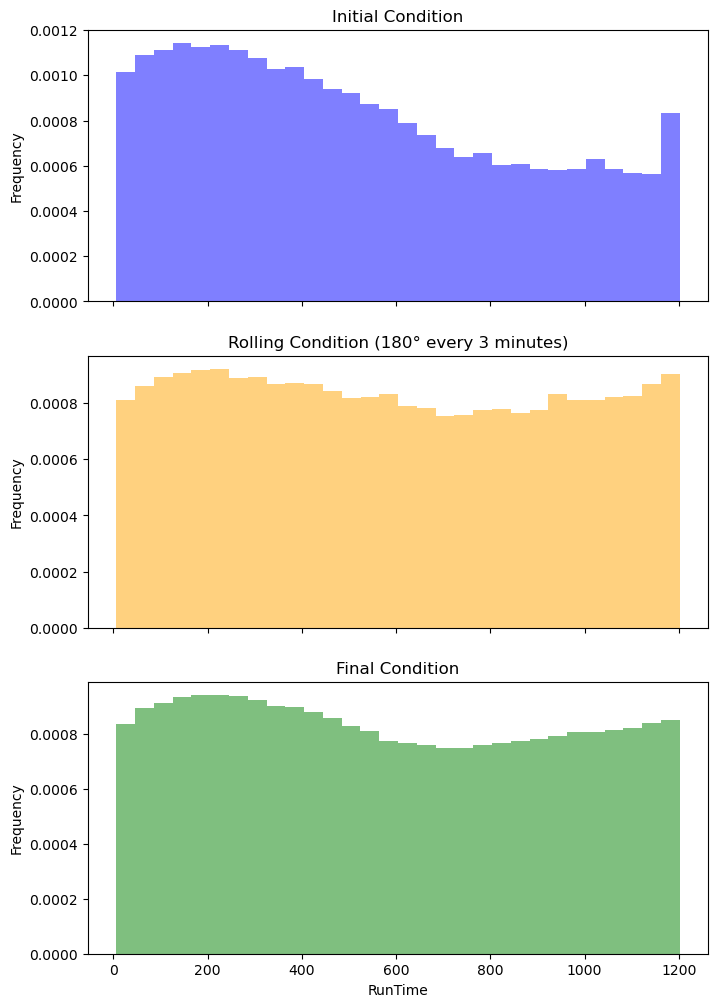

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

ax[0].hist(initial_df['RunTime'], bins=30, alpha=0.5, label='Initial', color='blue', density=True)
ax[0].set_ylabel('Frequency')
ax[0].set_title('Initial Condition')

ax[1].hist(rolling_df['RunTime'], bins=30, alpha=0.5, label='Rolling', color='orange', density=True)
ax[1].set_ylabel('Frequency')
ax[1].set_title('Rolling Condition (180° every 3 minutes)')

ax[2].hist(final_df['RunTime'], bins=30, alpha=0.5, label='Final', color='green', density=True)
ax[2].set_xlabel('RunTime')
ax[2].set_ylabel('Frequency')
ax[2].set_title('Final Condition')



Text(0.5, 1.0, 'Final Condition')

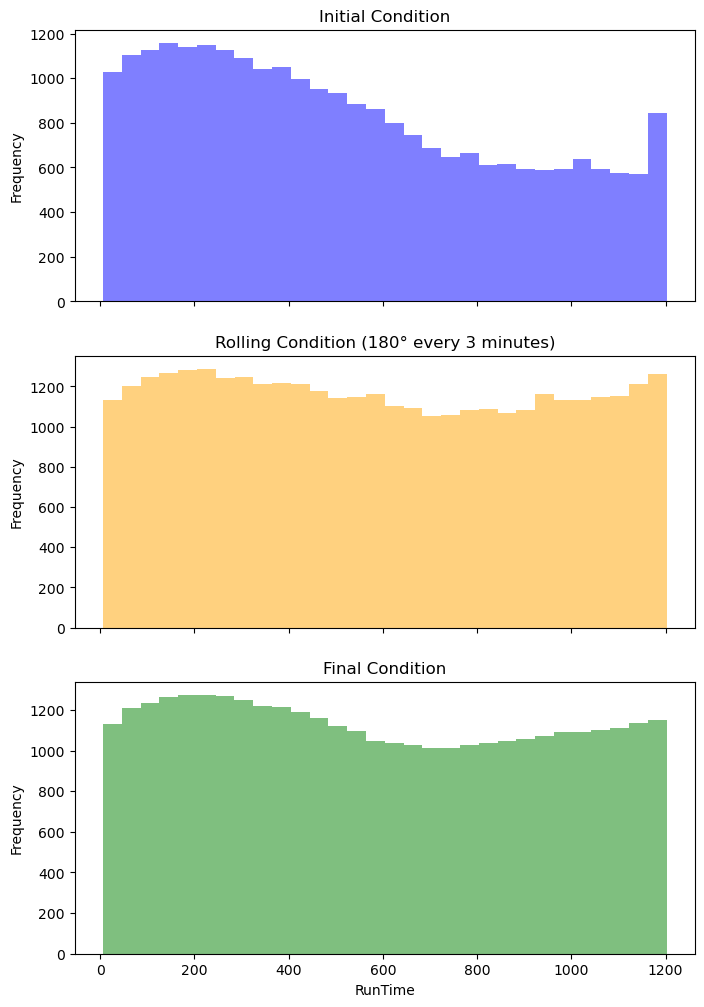

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

ax[0].hist(initial_df['RunTime'], bins=30, alpha=0.5, label='Initial', color='blue')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Initial Condition')

ax[1].hist(rolling_df['RunTime'], bins=30, alpha=0.5, label='Rolling', color='orange' )
ax[1].set_ylabel('Frequency')
ax[1].set_title('Rolling Condition (180° every 3 minutes)')

ax[2].hist(final_df['RunTime'], bins=30, alpha=0.5, label='Final', color='green')
ax[2].set_xlabel('RunTime')
ax[2].set_ylabel('Frequency')
ax[2].set_title('Final Condition')


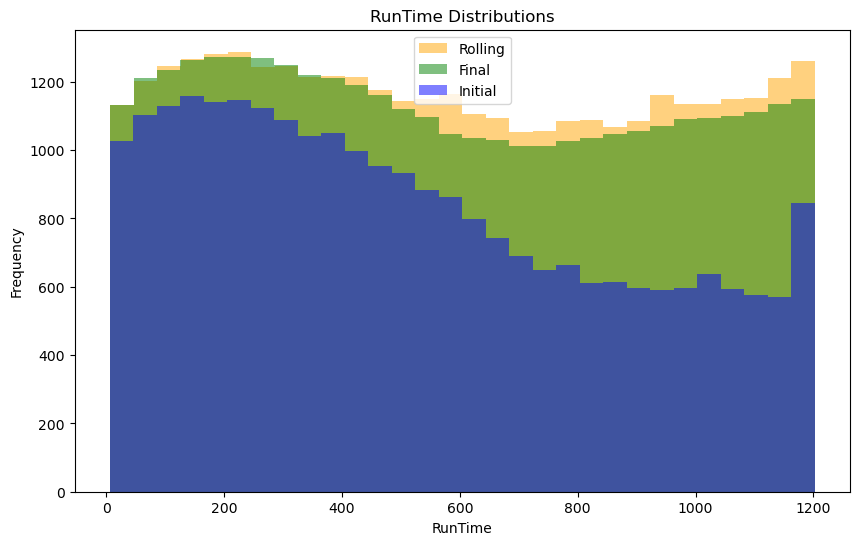

In [35]:

plt.figure(figsize=(10, 6))
plt.hist(rolling_df['RunTime'], bins=30, alpha=0.5, label='Rolling', color='orange')
plt.hist(final_df['RunTime'], bins=30, alpha=0.5, label='Final', color='green')
plt.hist(initial_df['RunTime'], bins=30, alpha=0.5, label='Initial', color='blue')
plt.xlabel('RunTime')
plt.ylabel('Frequency')
plt.title('RunTime Distributions')
plt.legend()

Initial Condition
KS statistic = 0.116
p-value = 5.32e-297

Rolling Condition
KS statistic = 0.021
p-value = 9.78e-14

Final Condition
KS statistic = 0.033
p-value = 7.75e-32



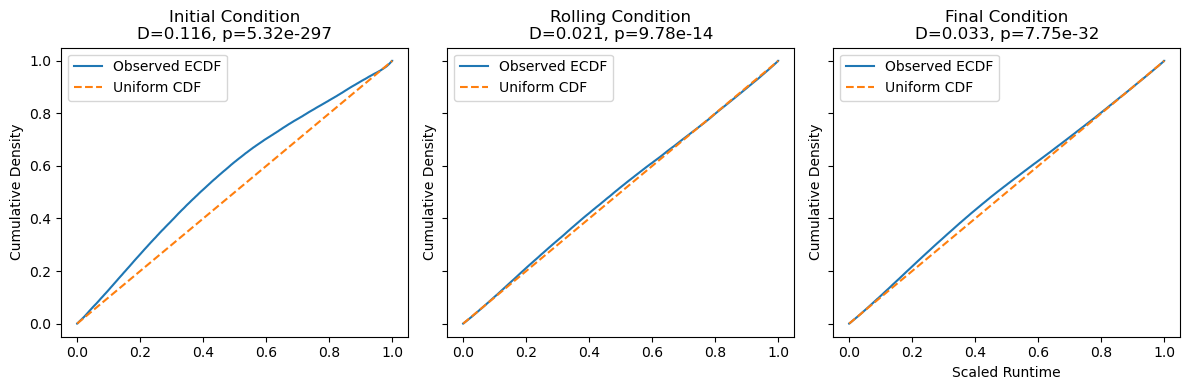

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# List of DataFrames and titles
dfs = [vert_df, initial_df, rolling_df, final_df]
titles = [
    "Initial Condition",
    "Rolling Condition",
    "Final Condition"
]

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=False, sharey=True)

for i, (df, title) in enumerate(zip(dfs, titles)):

    # Extract data
    data = np.array(df["RunTime"])

    # Scale to [0,1]
    scaled = (data - data.min()) / (data.max() - data.min())

    # Empirical CDF
    x = np.sort(scaled)
    n = len(x)
    ecdf = np.arange(1, n + 1) / n

    # Theoretical uniform CDF
    theoretical_x = np.linspace(0, 1, 1000)
    theoretical_cdf = theoretical_x

    # KS test
    ks_stat, p = kstest(scaled, "uniform")

    print(f"{title}")
    print(f"KS statistic = {ks_stat:.3f}")
    print(f"p-value = {p:.3g}\n")

    # Plot
    ax[i].step(
        x,
        ecdf,
        where="post",
        label="Observed ECDF"
    )

    ax[i].plot(
        theoretical_x,
        theoretical_cdf,
        "--",
        label="Uniform CDF"
    )

    ax[i].set_title(f"{title}\nD={ks_stat:.3f}, p={p:.3g}")
    ax[i].set_ylabel("Cumulative Density")
    ax[i].legend()

ax[-1].set_xlabel("Scaled Runtime")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'RoiY')

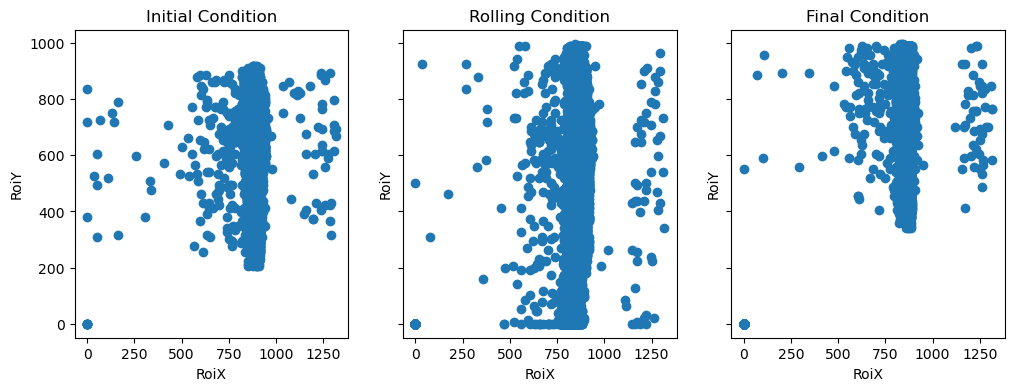

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

ax[0].scatter(initial_df['RoiX'], initial_df['RoiY'])
ax[0].set_title('Initial Condition')
ax[0].set_xlabel('RoiX')
ax[0].set_ylabel('RoiY')

ax[1].scatter(rolling_df['RoiX'], rolling_df['RoiY'])
ax[1].set_title('Rolling Condition')
ax[1].set_xlabel('RoiX')
ax[1].set_ylabel('RoiY')

ax[2].scatter(final_df['RoiX'], final_df['RoiY'])
ax[2].set_title('Final Condition')
ax[2].set_xlabel('RoiX')
ax[2].set_ylabel('RoiY')


In [23]:
## rolled every 3 minutes, so we can split the data into 180-second blocks and analyze the distribution of points within each block. We will also exclude points that are too close to the boundaries of each block (e.g., within 10 seconds of the start or end of a block) to avoid edge effects.

import numpy as np

block_length = 180   # seconds
buffer = 10          # seconds

# Copy to avoid modifying original
df2 = rolling_df.copy()

# Position within each 180-second block
position = df2["RunTime"] % block_length

# Keep only points that are at least 10 s away from the boundaries
keep = (position >= buffer) & (position <= block_length - buffer)

df2 = df2[keep].copy()

# Determine which 180 s block each point is in
block = (df2["RunTime"] // block_length).astype(int)

# Even blocks -> upright, odd blocks -> inverted
upright_df = df2[block % 2 == 0].copy()
invert_df = df2[block % 2 == 1].copy()

Text(0.5, 0, 'RoiX')

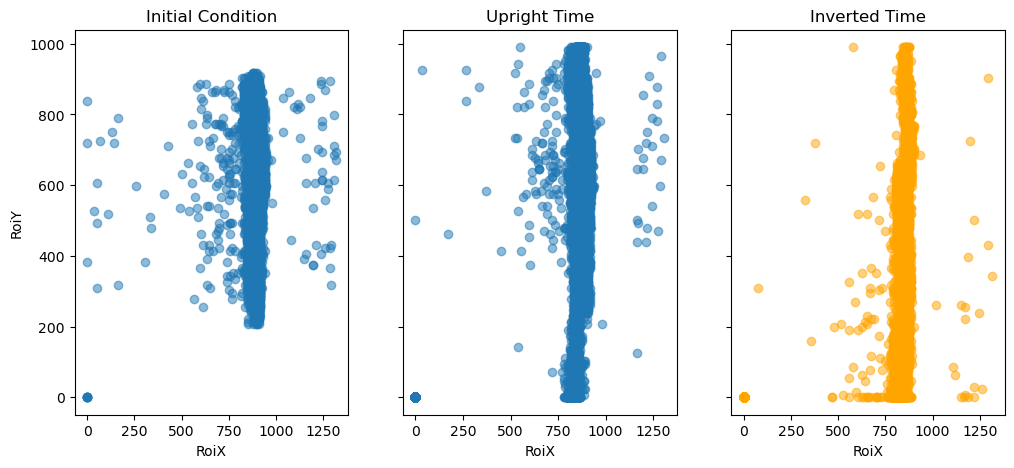

In [26]:
ax, ax = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

ax[0].scatter(initial_df['RoiX'], initial_df['RoiY'], alpha=0.5)
ax[0].set_title('Initial Condition')
ax[0].set_xlabel('RoiX')
ax[0].set_ylabel('RoiY')

ax[1].scatter(upright_df['RoiX'], upright_df['RoiY'], alpha=0.5)
ax[1].set_title('Upright Time')
ax[1].set_xlabel('RoiX')
#ax[1].set_ylabel('RoiY')

ax[2].scatter(invert_df['RoiX'], invert_df['RoiY'], alpha=0.5, color='orange')
ax[2].set_title('Inverted Time')
ax[2].set_xlabel('RoiX')
#ax[2].set_ylabel('RoiY')



In [30]:
first180_df = rolling_df[rolling_df['RunTime'] < 180].copy()
second180_df = rolling_df[(rolling_df['RunTime'] >= 180) & (rolling_df['RunTime'] < 360)].copy()
third180_df = rolling_df[(rolling_df['RunTime'] >= 360) & (rolling_df['RunTime'] < 540)].copy()
fourth180_df = rolling_df[(rolling_df['RunTime'] >= 540) & (rolling_df['RunTime'] < 720)].copy()


Text(0.5, 0, 'RoiX')

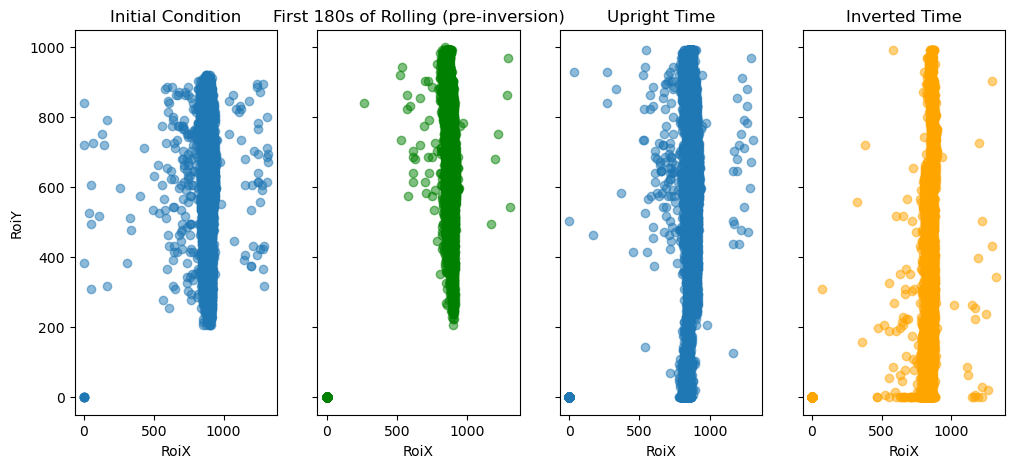

In [28]:
ax, ax = plt.subplots(1, 4, figsize=(12, 5), sharey=True)

ax[0].scatter(initial_df['RoiX'], initial_df['RoiY'], alpha=0.5)
ax[0].set_title('Initial Condition')
ax[0].set_xlabel('RoiX')
ax[0].set_ylabel('RoiY')

ax[1].scatter(first180_df['RoiX'], first180_df['RoiY'], alpha=0.5, color='green')
ax[1].set_title('First 180s of Rolling (pre-inversion)')
ax[1].set_xlabel('RoiX')

ax[2].scatter(upright_df['RoiX'], upright_df['RoiY'], alpha=0.5)
ax[2].set_title('Upright Time')
ax[2].set_xlabel('RoiX')
#ax[1].set_ylabel('RoiY')

ax[3].scatter(invert_df['RoiX'], invert_df['RoiY'], alpha=0.5, color='orange')
ax[3].set_title('Inverted Time')
ax[3].set_xlabel('RoiX')
#ax[2].set_ylabel('RoiY')



Text(0.5, 0, 'RoiX')

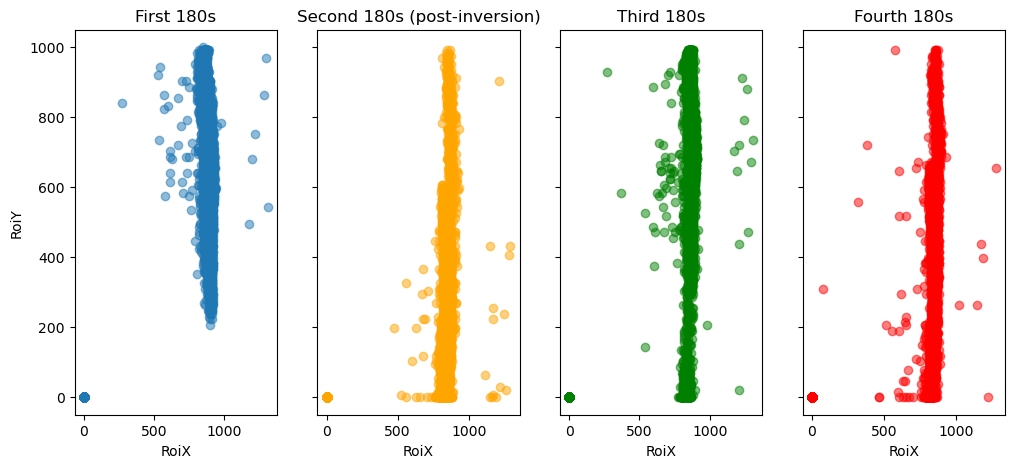

In [32]:
fig, ax = plt.subplots(1, 4, figsize=(12, 5), sharey=True)

ax[0].scatter(first180_df['RoiX'], first180_df['RoiY'], alpha=0.5)
ax[0].set_title('First 180s')
ax[0].set_xlabel('RoiX')
ax[0].set_ylabel('RoiY')

ax[1].scatter(second180_df['RoiX'], second180_df['RoiY'], alpha=0.5, color='orange')
ax[1].set_title('Second 180s (post-inversion)')
ax[1].set_xlabel('RoiX')

ax[2].scatter(third180_df['RoiX'], third180_df['RoiY'], alpha=0.5, color='green')
ax[2].set_title('Third 180s')
ax[2].set_xlabel('RoiX')

ax[3].scatter(fourth180_df['RoiX'], fourth180_df['RoiY'], alpha=0.5, color='red')
ax[3].set_title('Fourth 180s')
ax[3].set_xlabel('RoiX')


## Compare sideways run times to horizontal im not sure they are different and what would it mean if they are not

In [5]:
### Compiling RunTimes from directory of CSV files
## may also want to do this later with parquets could make it more intesting but to start keep it simple stupud

from pathlib import Path
import pandas as pd
import numpy as np

def compile_runtimes(directory):
    """
    Compile all values from the 'RunTime' column across all CSV files.

    Parameters
    ----------
    directory : str or Path
        Directory containing CSV files.

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame containing all runtime and ROI area values.

    n_files : int
        Number of CSV files that contained a 'RunTime' column.
    """
    runtimes = []
    n_files = 0

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)

        if "RunTime" in df.columns:
            runtimes.extend(df["RunTime"].dropna())
            n_files += 1


            
    results_df = pd.DataFrame({
        "RunTime": runtimes,
    })
    return results_df, n_files
   

In [6]:
vert_df, n_vert = compile_runtimes("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/Alex/hablab_AlexHighV/merged")

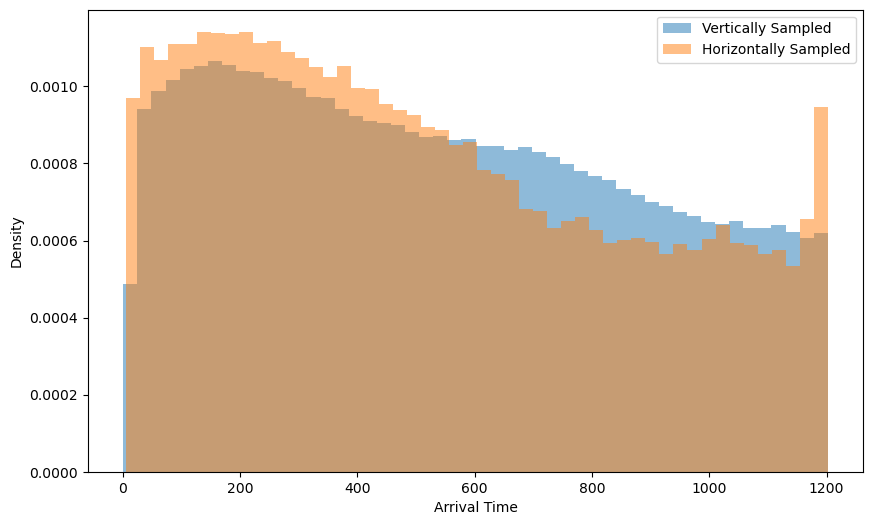

In [47]:
plt.figure(figsize=(10, 6))
plt.hist(vert_df["RunTime"], bins=50, alpha=0.5, label="Vertically Sampled", density=True)
plt.hist(initial_df["RunTime"], bins=50, alpha=0.5, label="Horizontally Sampled", density=True) 
plt.xlabel("Arrival Time")
plt.ylabel("Density")
plt.legend()

Vertically Sampling
KS statistic = 0.069
p-value = 0

Initial Condition
KS statistic = 0.116
p-value = 5.32e-297

Rolling Condition
KS statistic = 0.021
p-value = 9.78e-14

Final Condition
KS statistic = 0.033
p-value = 7.75e-32



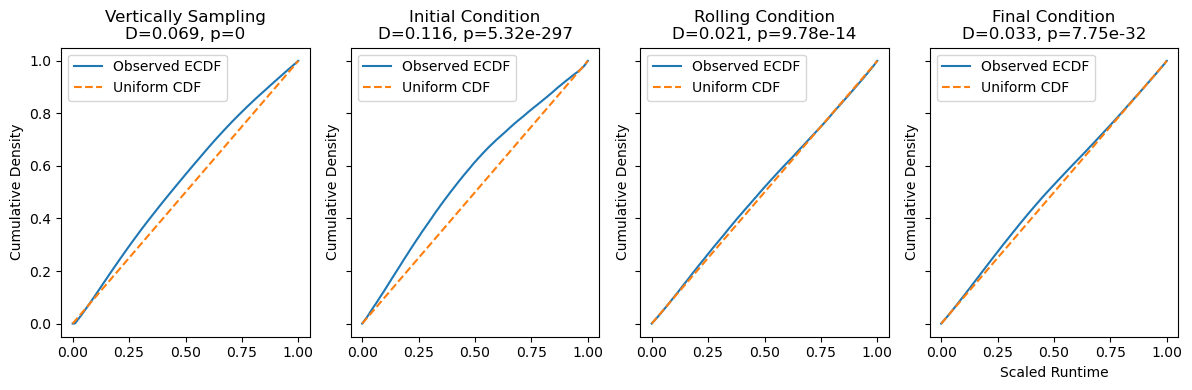

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# List of DataFrames and titles
dfs = [vert_df, initial_df, rolling_df, final_df]
titles = [
    "Vertically Sampling",
    "Initial Condition",
    "Rolling Condition",
    "Final Condition"
]

fig, ax = plt.subplots(1, 4, figsize=(12, 4), sharex=False, sharey=True)

for i, (df, title) in enumerate(zip(dfs, titles)):

    # Extract data
    data = np.array(df["RunTime"])

    # Scale to [0,1]
    scaled = (data - data.min()) / (data.max() - data.min())

    # Empirical CDF
    x = np.sort(scaled)
    n = len(x)
    ecdf = np.arange(1, n + 1) / n

    # Theoretical uniform CDF
    theoretical_x = np.linspace(0, 1, 1000)
    theoretical_cdf = theoretical_x

    # KS test
    ks_stat, p = kstest(scaled, "uniform")

    print(f"{title}")
    print(f"KS statistic = {ks_stat:.3f}")
    print(f"p-value = {p:.3g}\n")

    # Plot
    ax[i].step(
        x,
        ecdf,
        where="post",
        label="Observed ECDF"
    )

    ax[i].plot(
        theoretical_x,
        theoretical_cdf,
        "--",
        label="Uniform CDF"
    )

    ax[i].set_title(f"{title}\nD={ks_stat:.3f}, p={p:.3g}")
    ax[i].set_ylabel("Cumulative Density")
    ax[i].legend()

ax[-1].set_xlabel("Scaled Runtime")

plt.tight_layout()
plt.show()

In [19]:
initial_df.head()
#initial_df["ADCtime"].count()
files = initial_df["FileName"].unique()
files

array(['D20260813T152241_IFCB193_adc_only.csv',
       'D20260813T143617_IFCB193_adc_only.csv',
       'D20260813T145929_IFCB193_adc_only.csv'], dtype=object)

In [ ]:
dfs = [initial_df, rolling_df, final_df]
names = ["initial", "rolling", "Final"]
concs = []
files_results = []
for df in dfs:
    files = df["FileName"].unique()
    for file in files:
        working_df = df[df["FileName"]== file].copy()
        volumeAnalyzed = working_df["VolumeAnalyzed"].max()
        particles = working_df["ADCtime"].count()
        concentration = particles / volumeAnalyzed
        concs.append(concentration)
        files_results.append(file)


In [36]:

dfs = [initial_df, rolling_df, final_df]
names = ["Initial", "Rolling", "Final"]
volumes=[]
particles= []
concs = []
files_results = []
conditions = []

for df, condition in zip(dfs, names):
    files = df["FileName"].unique()

    for file in files:
        working_df = df[df["FileName"] == file]

        volumeAnalyzed = working_df["VolumeAnalyzed"].max()
        particle = working_df["VolumeAnalyzed"].count()
        concentration = particle / volumeAnalyzed

        volumes.append(volumeAnalyzed)
        particles.append(particle)
        concs.append(concentration)
        files_results.append(file)
        conditions.append(condition)

results_df = pd.DataFrame({
    "FileName": files_results,
    "ParticleCount": particles,
    "VolumeAnalyzed": volumes,
    "Condition": conditions,
    "Concentration": concs
})

In [45]:
results_df["DateTime"] = pd.to_datetime(
    results_df["FileName"].str.extract(r"D(\d{8}T\d{6})")[0],
    format="%Y%m%dT%H%M%S"
)
results_df

,FileName,ParticleCount,VolumeAnalyzed,Condition,Concentration,DateTime
0,D20260813T152241_IFCB193_adc_only.csv,10779,1.310656,Initial,8224.126181,2026-08-13 15:22:41
1,D20260813T143617_IFCB193_adc_only.csv,5138,3.239210,Initial,1586.189049,2026-08-13 14:36:17
2,D20260813T145929_IFCB193_adc_only.csv,9493,1.750638,Initial,5422.593545,2026-08-13 14:59:29
3,D20260813T161555_IFCB193_adc_only.csv,11640,1.013300,Rolling,11487.216038,2026-08-13 16:15:55
4,D20260813T163908_IFCB193_adc_only.csv,11788,0.956151,Rolling,12328.599827,2026-08-13 16:39:08
5,D20260813T155242_IFCB193_adc_only.csv,11591,1.024157,Rolling,11317.605810,2026-08-13 15:52:42
6,D20260813T174956_IFCB193_adc_only.csv,11082,1.197997,Final,9250.439705,2026-08-13 17:49:56
7,D20260813T172643_IFCB193_adc_only.csv,11513,1.060185,Final,10859.426545,2026-08-13 17:26:43
8,D20260813T170330_IFCB193_adc_only.csv,11366,1.119499,Final,10152.752010,2026-08-13 17:03:30


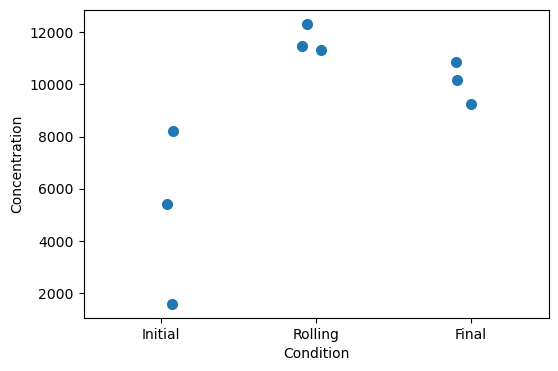

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.stripplot(
    data=results_df,
    x="Condition",
    y="Concentration",
    #jitter=True,   # spreads points horizontally
    size=8
)

plt.xlabel("Condition")
plt.ylabel("Concentration")
plt.show()

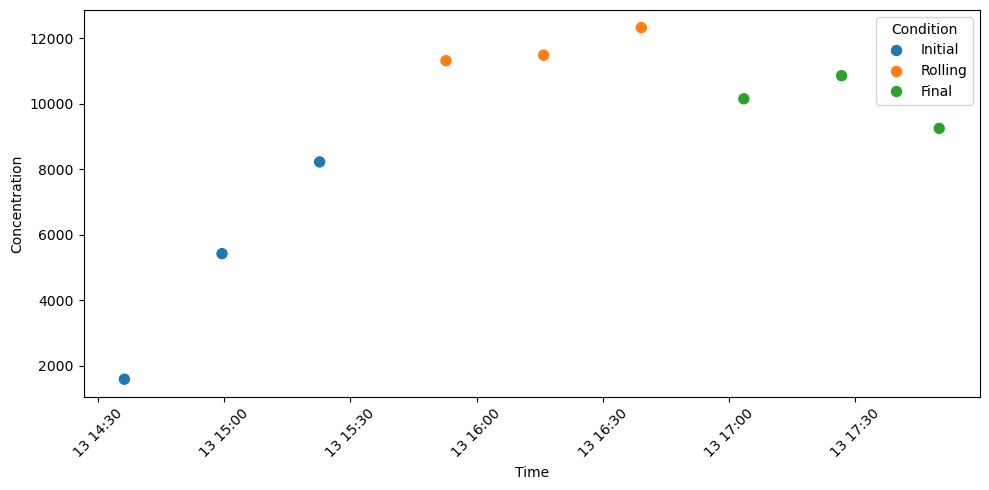

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=results_df,
    x="DateTime",
    y="Concentration",
    hue="Condition",
    s=80
)

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
test_df = initial_df[initial_df["FileName"]=="D20260813T143617_IFCB193_adc_only.csv"]

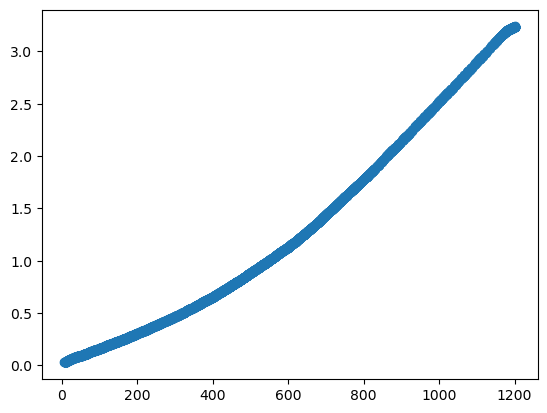

In [39]:
plt.scatter(test_df["ADCtime"], test_df["VolumeAnalyzed"])

In [44]:
test_df["InhibitTime"].tail()

15912    424.122917
15913    424.206458
15914    424.286979
15915    424.370833
15916    424.454236
Name: InhibitTime, dtype: float64